### Task 1: Designing a Heuristic for a Warehouse Robot

In [50]:
import math
import networkx as nx
import matplotlib.pyplot as plt

# 1. Coordinates of warehouse locations
locations = {
    "Receiving_Area": (0, 0),
    "Storage_A": (2, 1),
    "Storage_B": (1, 4),
    "Sorting_Area": (4, 2),
    "Inspection_Area": (5, 5),
    "Packing_Station": (7, 6)
}


# 2. Weighted warehouse graph
warehouse_graph = {
    "Receiving_Area": {
        "Storage_A": 2.2,
        "Storage_B": 4.1
    },

    "Storage_A": {
        "Sorting_Area": 2.2
    },

    "Storage_B": {
        "Inspection_Area": 5.0,
        "Sorting_Area": 6.0
    },

     # add remaining nodes and their connections as given in the lab task document.
    "Sorting_Area": {
        "Inspection_Area": 3.2,
        "Packing_Station": 5.0
    },

    "Inspection_Area": {
        "Packing_Station": 2.2
    },

    "Packing_Station": {}
}


# 3. Euclidean heuristic
def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]

    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    return distance

# 4. Calculate heuristic values

goal = "Packing_Station"

print("Heuristic Values")
print("----------------")

for location in locations:
    print(f"{location}: "f"{heuristic(location, goal):.2f}")

Heuristic Values
----------------
Receiving_Area: 9.22
Storage_A: 7.07
Storage_B: 6.32
Sorting_Area: 5.00
Inspection_Area: 2.24
Packing_Station: 0.00


#### NetworkX visualization: Since Task 1 does not ask GBFS/A* to find a path, you are supposed highlight the actual minimum-cost path merely for visualization:

In [51]:
# 5. Create NetworkX graph

G = nx.DiGraph()

for node, neighbors in warehouse_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(
            node,
            neighbor,
            weight=cost
        )
# 6. Find minimum-cost path
## The primary function to find the shortest path in the Python networkx library 
### 1. Unweighted shortest path (ignores 'weight', finds fewest number of edges)
### 2. Weighted shortest path (minimizes the sum of the 'weight' attribute)
solution_path = nx.shortest_path( # reaturn the path e.g. A → B → C
    G,
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)
solution_cost = nx.shortest_path_length( #return the numeric value
     G,#pass the graph object
        source="Receiving_Area",
        target="Packing_Station",
        weight="weight"
)
print("\nMinimum cost path:")
print(" -> ".join(solution_path))
print(f"Total cost: {solution_cost:.2f}")


Minimum cost path:
Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40


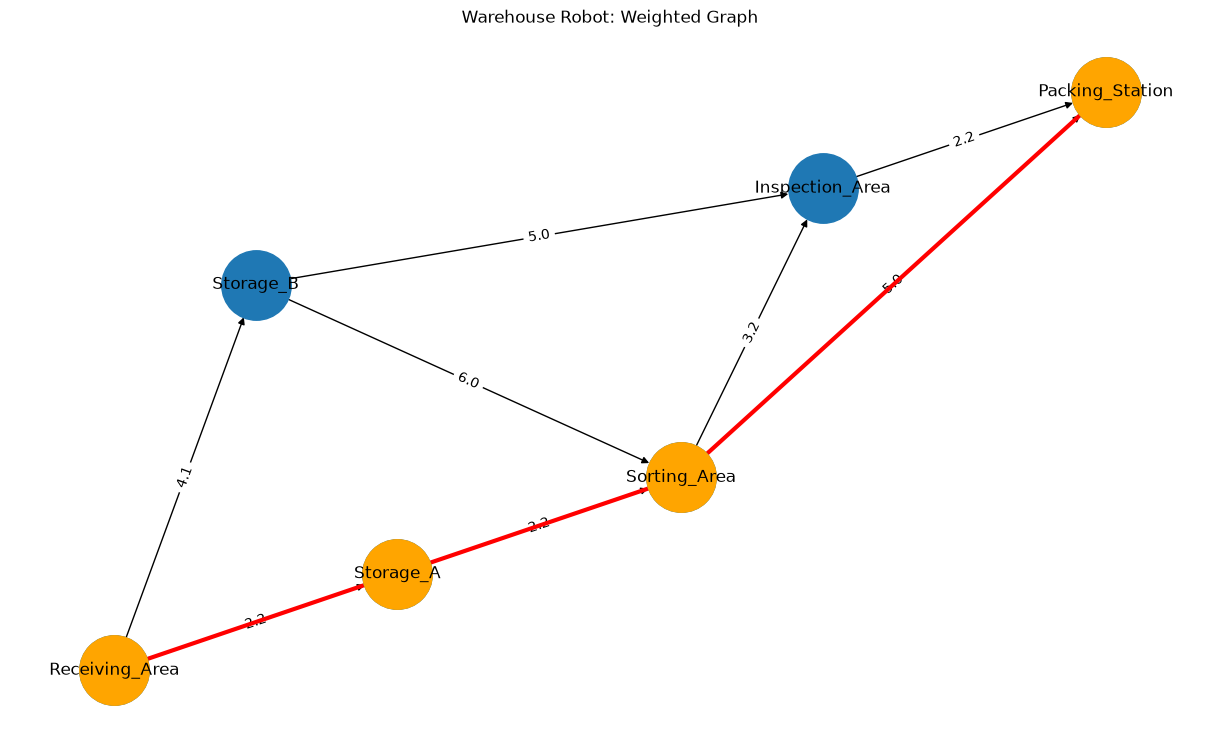

In [52]:
# 7. Visualize graph

pos = locations
plt.figure(figsize=(12, 7))

# write code to draw the graph with nodes, edges, and labels along with the highlighted solution path.
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    arrows=True
)
edge_labels = nx.get_edge_attributes(
    G,
    "weight"
)
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)
solution_edges = list(zip(solution_path, solution_path[1:]))
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=solution_edges,
    width=3,
    edge_color="red",
    arrows=True
)
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=solution_path,
    node_color="orange",
    node_size=2500
)

plt.title("Warehouse Robot: Weighted Graph")
plt.axis("off")
plt.show()

In [53]:
# 8. Verify heuristic condition

print("\nHeuristic Condition Verification")
print("***********************************")

for node in warehouse_graph:
    for neighbor, cost in warehouse_graph[node].items():
        h_node = heuristic(node, goal)
        h_neighbor = heuristic(neighbor, goal)
        condition = h_node <= cost + h_neighbor
        
        print(f"{node} -> {neighbor}: "f"{h_node:.2f} <= "f"{cost:.2f} + {h_neighbor:.2f} = "f"{cost + h_neighbor:.2f} : "f"{condition}")


Heuristic Condition Verification
***********************************
Receiving_Area -> Storage_A: 9.22 <= 2.20 + 7.07 = 9.27 : True
Receiving_Area -> Storage_B: 9.22 <= 4.10 + 6.32 = 10.42 : True
Storage_A -> Sorting_Area: 7.07 <= 2.20 + 5.00 = 7.20 : True
Storage_B -> Inspection_Area: 6.32 <= 5.00 + 2.24 = 7.24 : True
Storage_B -> Sorting_Area: 6.32 <= 6.00 + 5.00 = 11.00 : True
Sorting_Area -> Inspection_Area: 5.00 <= 3.20 + 2.24 = 5.44 : True
Sorting_Area -> Packing_Station: 5.00 <= 5.00 + 0.00 = 5.00 : True
Inspection_Area -> Packing_Station: 2.24 <= 2.20 + 0.00 = 2.20 : False


write down your observation in one line:
Euclidean distance is suitable because the warehouse locations have 2D coordinates. With the given edge costs the heuristic condition fails only for Inspection_Area -> Packing_Station because 2.24 <= 2.20 is false.

### Task 2: Greedy Best-First Search for Airport Baggage Handling

In [3]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# 1. Airport coordinates

locations = {
    "Baggage_Area": (0, 0),
    "Security": (2, 1),
    "Checkpoint": (1, 4),
    "Food_Court": (4, 2),
    # add remaining nodes and their coordinates as given in the lab task document.
    "Terminal_Hall": (5, 5),
    "Departure_Gate": (8, 6)
}

# 2. Weighted graph


airport_graph = {
    "Baggage_Area": {
        "Security": 2.2,
        "Checkpoint": 4.1
    },

    "Security": {
        "Food_Court": 2.2
    },

    "Checkpoint": {
        "Terminal_Hall": 5.0
    },

    "Food_Court": {
        "Terminal_Hall": 3.2,
        "Departure_Gate": 6.0
    },

    "Terminal_Hall": {
        "Departure_Gate": 3.2
    },

    "Departure_Gate": {}
}

# 3. Euclidean heuristic

def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]

    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    return distance


# 4. GBFS


def greedy_best_first_search(start, goal, graph, heuristic_function):
    # write code to implement the Greedy Best-First Search algorithm using a priority queue (min-heap) 
    # to explore nodes based on their heuristic values. Keep track of the path and expansion order.
    
    frontier = []

    heapq.heappush(frontier, (heuristic_function(start, goal), start))

    visited = set()

    came_from = {
        start: None
    }

    expansion_order = []

    while frontier:

        h_value, current = heapq.heappop(frontier)

        if current in visited:
            continue

        visited.add(current)
        expansion_order.append(current)

        if current == goal:
            break

        for neighbor in graph[current]:

            if neighbor not in visited and neighbor not in came_from:
                came_from[neighbor] = current
                heapq.heappush(frontier, (heuristic_function(neighbor, goal), neighbor))
    
    
    # Reconstruct path
    
    if goal not in came_from:
        return None, 0, expansion_order

    path = []

    current = goal

    while current is not None:
        path.append(current)
        current = came_from[current]

    path.reverse()
    

    # Calculate actual path cost
    
    total_cost = 0

    for i in range(len(path) - 1):
        total_cost += graph[path[i]][path[i + 1]]

    return path, total_cost, expansion_order



# 5. Run GBFS


# define the start state 
start = "Baggage_Area"

# define the goal state
goal = "Departure_Gate"

# call the greedy_best_first_search function with the start state, goal state, and airport_graph as arguments
path, total_cost, expansion_order = greedy_best_first_search(start, goal, airport_graph, heuristic)

print("GBFS")
print("--------------------------------")
print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

GBFS
--------------------------------
Expansion order:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Solution path:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Total path cost: 12.30


#### NetworkX visualization

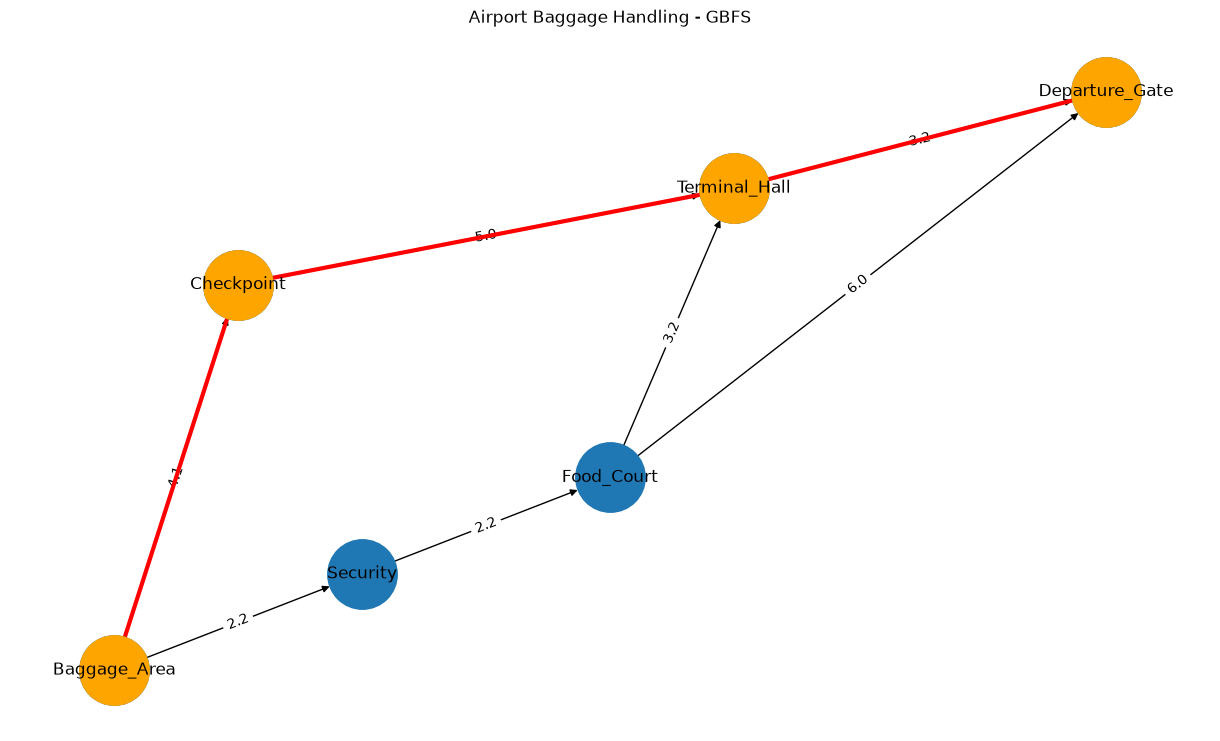

In [55]:
# 6. NetworkX visualization

G = nx.DiGraph()

for node, neighbors in airport_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(
            node,
            neighbor,
            weight=cost
        )


pos = locations

plt.figure(figsize=(12, 7))

# write code to draw the graph with nodes, edges, and labels along with the highlighted solution path.
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    arrows=True
)

edge_labels = nx.get_edge_attributes(
    G,
    "weight"
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

solution_edges = list(zip(path, path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=solution_edges,
    edge_color="red",
    width=3,
    arrows=True
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=path,
    node_color="orange",
    node_size=2500
)

plt.title("Airport Baggage Handling - GBFS")
plt.axis("off")
plt.show()

### Task 3: A* Search for Emergency Supply Robot

In [5]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt


# 1. Hospital coordinates


hospital_locations = {
    "Pharmacy": (0, 0),
    "Main_Corridor": (2, 1),
    "Patient_Wing": (1, 4),
    "Nursing_Station": (4, 2),
    "Laboratory": (5, 5),
    "Emergency_Ward": (8, 6)
}


# 2. Hospital weighted graph


hospital_graph = {
    "Pharmacy": {
        "Main_Corridor": 2.2,
        "Patient_Wing": 4.1
    },

    "Main_Corridor": {
        "Nursing_Station": 2.2
    },

    "Patient_Wing": {
        "Laboratory": 5.0
    },

    # add remaining nodes and their connections as given in the lab task document.

    "Nursing_Station": {
        "Laboratory": 3.2,
        "Emergency_Ward": 6.0
    },

    "Laboratory": {
        "Emergency_Ward": 3.2
    },

    "Emergency_Ward": {}
}

# 3. Euclidean heuristic


def hospital_heuristic(current, goal):
    x1, y1 = hospital_locations[current]
    x2, y2 = hospital_locations[goal]

    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    return distance

# 4. Path reconstruction

def reconstruct_path(came_from, current):

    path = []

    while current is not None:
        path.append(current)
        current = came_from[current]

    path.reverse()

    return path

# 5. A* Search
def a_star_search(start, goal, graph):
    # write code to implement the A* Search algorithm using a priority queue (min-heap) 
    # to explore nodes based on their f(n) = g(n) + h(n) values. Keep track of the path, expansion order, and g(n) costs.
    frontier = []

    heapq.heappush(frontier, (hospital_heuristic(start, goal), start))

    came_from = {
        start: None
    }

    g_cost = {
        start: 0
    }

    expansion_order = []

    visited = set()

    while frontier:
        f_value, current = heapq.heappop(frontier)
        if current in visited:
            continue
        visited.add(current)
        expansion_order.append(current)

        if current == goal:
            path = reconstruct_path(came_from, current)

            return (path, g_cost[current], expansion_order, g_cost)

        for neighbor, cost in graph[current].items():

            new_g_cost = g_cost[current] + cost

            if (neighbor not in g_cost or new_g_cost < g_cost[neighbor]):

                g_cost[neighbor] = new_g_cost
                came_from[neighbor] = current
                f_value = (new_g_cost + hospital_heuristic(neighbor, goal))

                heapq.heappush(frontier, (f_value, neighbor))
    return None, 0, expansion_order, g_cost

# 6. Run A*

# define the start state
start = "Pharmacy"

# define the goal state
goal = "Emergency_Ward"

# call the a_star_search function with the start state, goal state, and hospital_graph as arguments
path, total_cost, expansion_order, g_cost = a_star_search(start, goal, hospital_graph)

print("A* Search")
print("--------------------------------")

print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

A* Search
--------------------------------
Expansion order:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Solution path:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Total path cost: 10.40


#### g(n), h(n), f(n) table

In [6]:
# you may also replace it with dataframe it is completely your own choice

print("\nA* Node Information")
print("*********************")
print(
    f"{'Node':20s}" #'Node' → the text to print, 20 → use 20 spaces/characters of width, s → treat it as a string
    f"{'g(n)':>10s}"
    f"{'h(n)':>10s}"
    f"{'f(n)':>10s}"
)

for node in expansion_order:

    g = g_cost[node]
    h = hospital_heuristic(node, goal)
    f = g + h

    print(
        f"{node:20s}"
        f"{g:10.2f}"
        f"{h:10.2f}"
        f"{f:10.2f}"
    )


A* Node Information
*********************
Node                      g(n)      h(n)      f(n)
Pharmacy                  0.00     10.00     10.00
Main_Corridor             2.20      7.81     10.01
Nursing_Station           4.40      5.66     10.06
Emergency_Ward           10.40      0.00     10.40


#### NetworkX visualization

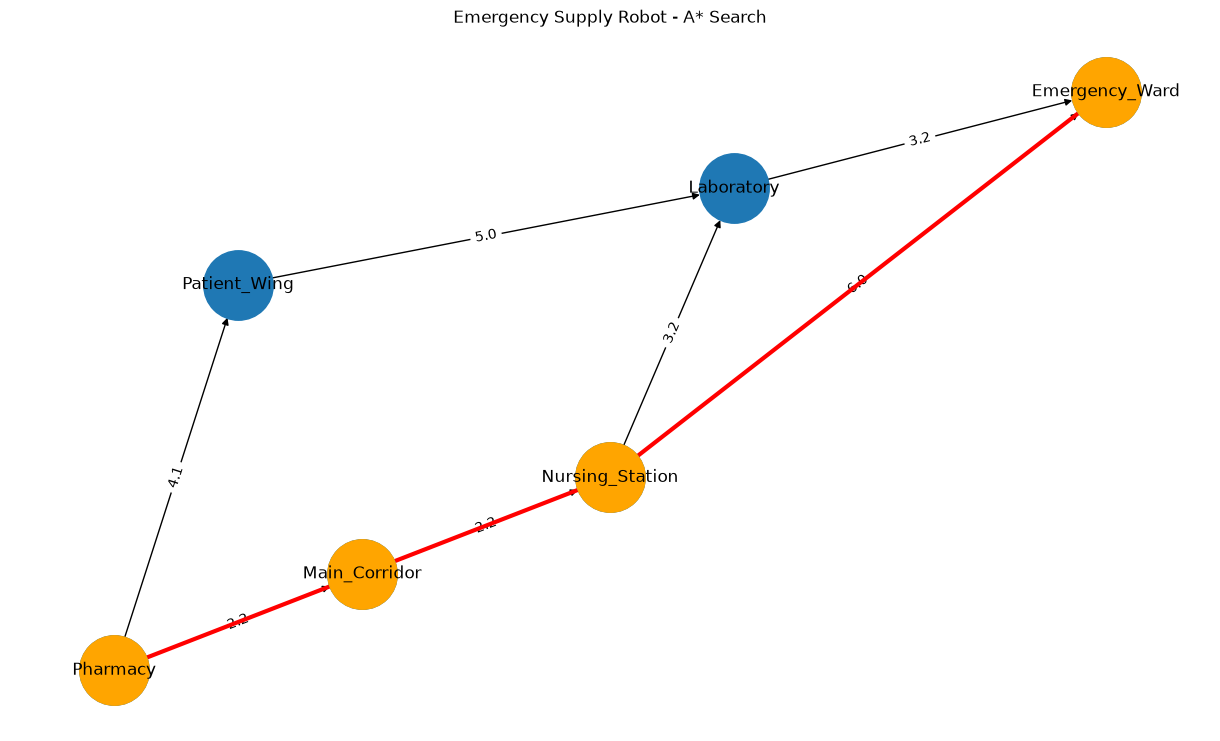

In [7]:
# 7. NetworkX visualization
G = nx.DiGraph()

for node, neighbors in hospital_graph.items():

    for neighbor, cost in neighbors.items():

        G.add_edge(
            node,
            neighbor,
            weight=cost
        )


pos = hospital_locations

plt.figure(figsize=(12, 7))

# write code to draw the graph with nodes, edges, and labels along with the highlighted solution path.

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    arrows=True
)

edge_labels = nx.get_edge_attributes(
    G,
    "weight"
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

solution_edges = list(
    zip(
        path,
        path[1:]
    )
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=solution_edges,
    edge_color="red",
    width=3,
    arrows=True
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=path,
    node_color="orange",
    node_size=2500
)

plt.title("Emergency Supply Robot - A* Search")
plt.axis("off")
plt.show()

GBFS would primarily ask:

"Which node appears closest to the Emergency Ward?"

A* instead asks:

"Considering both the cost already travelled and the estimated remaining cost, which node has the lowest estimated total cost?"

### Task 4: Weighted A* for Autonomous Delivery Drone

In [59]:
import math
import heapq
import pandas as pd

# 1. Location Coordinates

locations = {
    "Distribution_Center": (0, 0),
    "Zone_A": (2, 1),
    "Zone_B": (1, 4),
    # add remaining nodes and their coordinates as given in the lab task document.
    "Zone_C": (4, 2),
    "Zone_D": (5, 5),
    "Customer_Building": (8, 6)
}

# 2. Weighted Graph

graph = {
    "Distribution_Center": {
        "Zone_A": 2.2,
        "Zone_B": 3.0
    },

    "Zone_A": {
        "Zone_C": 2.2
    },

    "Zone_B": {
        "Zone_D": 5.0
    },

    # add remaining nodes and their connections as given in the lab task document.
    "Zone_C": {
        "Zone_D": 3.2,
        "Customer_Building": 6.0
    },

    "Zone_D": {
        "Customer_Building": 3.2
    },

    "Customer_Building": {}
}

# 3. Euclidean Heuristic

def heuristic(node, goal):
    x1, y1 = locations[node]
    x2, y2 = locations[goal]

    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

# 4. Display Heuristic Values
goal = "Customer_Building"

heuristic_data = []

for node in locations:

    heuristic_data.append({"Node": node, "h(n)": round(heuristic(node, goal), 2)})

heuristic_df = pd.DataFrame(heuristic_data)

print("Heuristic Values:")
print(heuristic_df.to_string(index=False))

# 5. Weighted A* Search
# f(n) = g(n) + w * h(n)

def weighted_a_star(start, goal, graph, weight):
    # use same structure as A* search, but modify the f(n) calculation to include the weight parameter.
    frontier = []

    heapq.heappush(frontier, (weight * heuristic(start, goal), start))

    parent = {
        start: None
    }

    g_cost = {
        start: 0
    }

    expansion_order = []

    visited = set()

    while frontier:
        f_value, current = heapq.heappop(frontier)
        if current in visited:
            continue

        visited.add(current)
        expansion_order.append(current)

        if current == goal:
            path = []

            while current is not None:
                path.append(current)
                current = parent[current]
            path.reverse()
            return path, g_cost[goal], expansion_order
        
        for neighbor, cost in graph[current].items():
            new_g_cost = g_cost[current] + cost
            if (neighbor not in g_cost or new_g_cost < g_cost[neighbor]):
                g_cost[neighbor] = new_g_cost
                parent[neighbor] = current
                f_value = (new_g_cost + weight * heuristic(neighbor, goal))

                heapq.heappush(frontier, (f_value, neighbor))
    return None, 0, expansion_order

# 6. Run Weighted A* for All Required Weights
start = "Distribution_Center"
goal = "Customer_Building"

weights = [1, 1.5, 2, 3]

results = []

for w in weights:

    path, cost, expansion_order = weighted_a_star(start, goal, graph, w)

    results.append({
        "Weight": w,
        "Solution Path": " -> ".join(path),
        "Total Cost": round(cost, 2),
        "Nodes Expanded": len(expansion_order),
        "Expansion Order": " -> ".join(expansion_order)
    })


# 7. Display Results in dataframe

results_df = pd.DataFrame(results)

print("\nWeighted A* Results:")
print(results_df[["Weight", "Solution Path", "Total Cost", "Nodes Expanded"]].to_string(index=False))

# 8. Display Detailed Expansion Orders

print("\nDetailed Expansion Orders:")

for result in results:
    print(f"w = {result['Weight']}: "f"{result['Expansion Order']}")

# ***
# Expected Main Results
# ***

# w = 1:
# Distribution_Center → Zone_A → Zone_C → Customer_Building
# Cost = 10.4
#
# w = 1.5:
# Distribution_Center → Zone_A → Zone_C → Customer_Building
# Cost = 10.4
#
# w = 2:
# Distribution_Center → Zone_B → Zone_D → Customer_Building
# Cost = 11.2
#
# w = 3:
# Distribution_Center → Zone_B → Zone_D → Customer_Building
# Cost = 11.2

Heuristic Values:
               Node  h(n)
Distribution_Center 10.00
             Zone_A  7.81
             Zone_B  7.28
             Zone_C  5.66
             Zone_D  3.16
  Customer_Building  0.00

Weighted A* Results:
 Weight                                                Solution Path  Total Cost  Nodes Expanded
    1.0 Distribution_Center -> Zone_A -> Zone_C -> Customer_Building        10.4               5
    1.5 Distribution_Center -> Zone_A -> Zone_C -> Customer_Building        10.4               4
    2.0 Distribution_Center -> Zone_B -> Zone_D -> Customer_Building        11.2               4
    3.0 Distribution_Center -> Zone_B -> Zone_D -> Customer_Building        11.2               4

Detailed Expansion Orders:
w = 1: Distribution_Center -> Zone_A -> Zone_C -> Zone_B -> Customer_Building
w = 1.5: Distribution_Center -> Zone_A -> Zone_C -> Customer_Building
w = 2: Distribution_Center -> Zone_B -> Zone_D -> Customer_Building
w = 3: Distribution_Center -> Zone_B -> Zone_D ->

#### NetworkX visualization

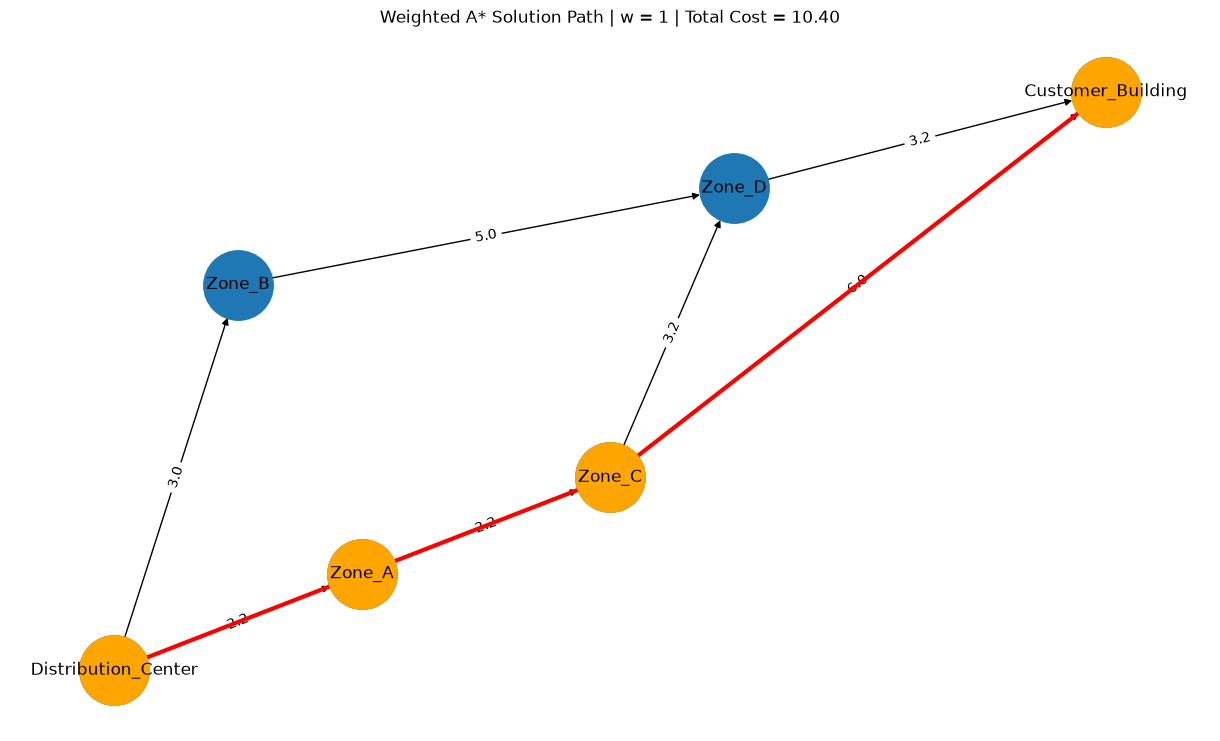

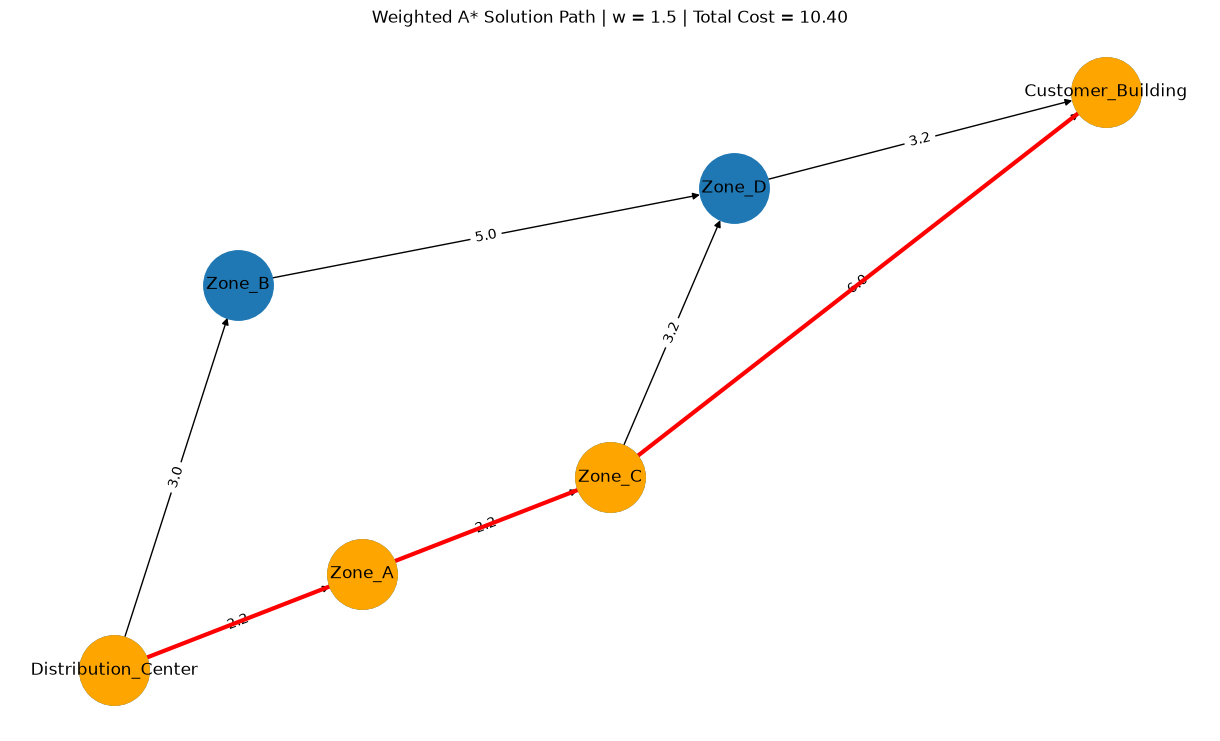

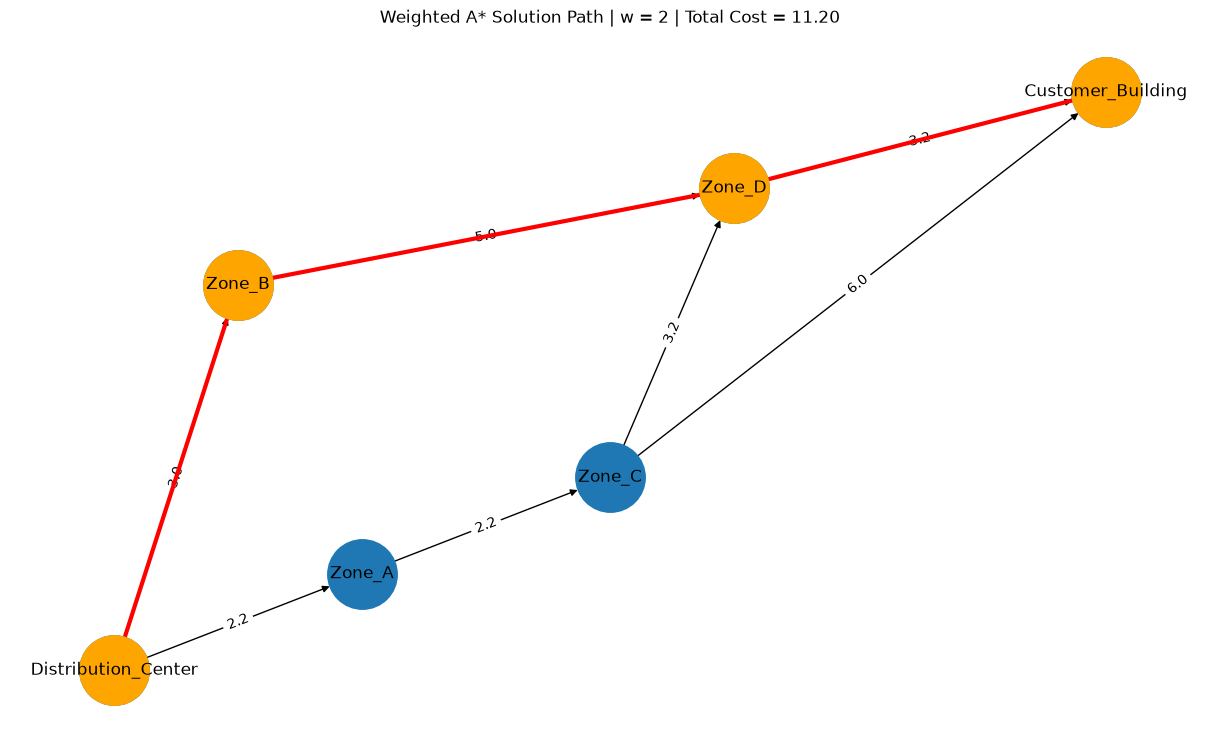

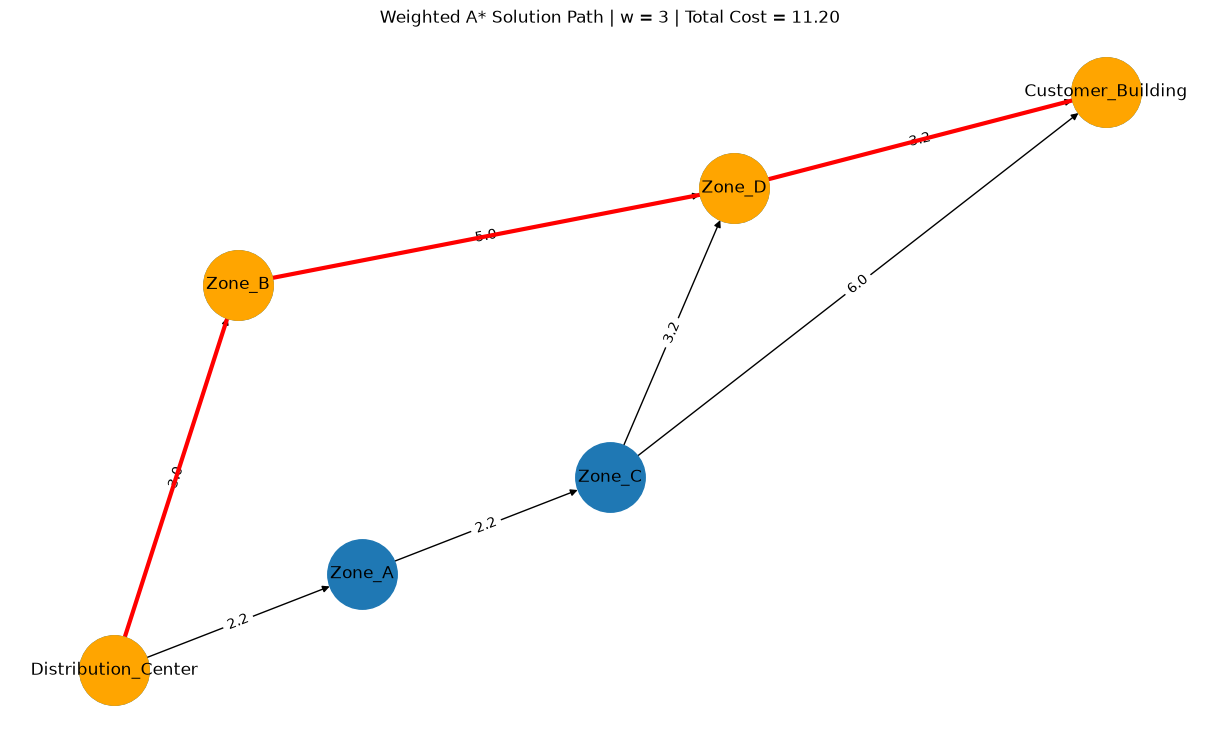

In [61]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create NetworkX Graph
G = nx.DiGraph()

# Add nodes with their coordinates
for node, position in locations.items():
    G.add_node(node, pos=position)

# Add weighted edges
for node, neighbors in graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(
            node,
            neighbor,
            weight=cost
        )

# 2. Node Positions
pos = locations

# 3. Visualize Weighted A* Result for Each Weight
for w in weights:

    # Run Weighted A*
    path, cost, expansion_order = weighted_a_star(start, goal, graph, w)

    plt.figure(figsize=(12, 7))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2500,
        arrows=True
    )

    edge_labels = nx.get_edge_attributes(
        G,
        "weight"
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels
    )

    solution_edges = list(zip(path, path[1:]))

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=solution_edges,
        edge_color="red",
        width=3,
        arrows=True
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=path,
        node_color="orange",
        node_size=2500
    )
    
    
    plt.title(f"Weighted A* Solution Path | w = {w} | "f"Total Cost = {cost:.2f}")

    plt.axis("off")

    plt.show()

#### Expansion order

This means:

In what order did the search algorithm remove/select nodes from the frontier and process them?

For example:

Expanded:
S → A → B → C → D → G

The algorithm may explore some nodes that are ultimately not part of the final route.

#### Solution path

This means:

Which nodes form the final route from start to goal?

For example:

Solution:
S → A → C → G

Here:

Expansion order:  S → A → B → C → D → G
Solution path:    S → A → C → G